In [32]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [ ]:
df = pd.read_excel("Online Retail.xlsx")

In [ ]:
df.head()

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
df.shape

(541909, 8)

In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df = df.dropna(subset=['CustomerID'])

In [8]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [9]:
df = df.dropna(subset=['Description'])

In [10]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [11]:
# Remove cancelled orders
df = df[
    ~df['InvoiceNo'].astype(str).str.startswith('C')
]

# Remove negative quantities
df = df[df['Quantity'] > 0]

# Remove zero or negative prices
df = df[df['UnitPrice'] > 0]

In [12]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [13]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [14]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [15]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

In [16]:
rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [17]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[['Recency','Frequency','Monetary']]
)

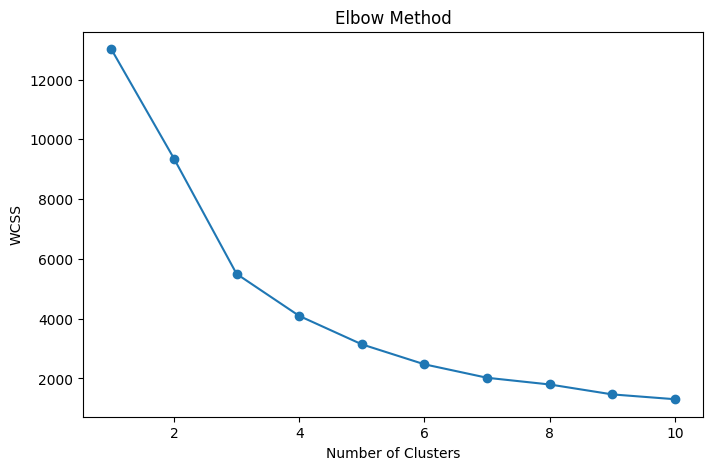

In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [20]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm['Cluster'] = kmeans.fit_predict(
    rfm_scaled
)

In [21]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


In [22]:
cluster_map = {
    0:'High Value Customers',
    1:'Regular Customers',
    2:'At Risk Customers',
    3:'New Customers'
}

rfm['Customer_Segment'] = (
    rfm['Cluster']
    .map(cluster_map)
)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Customer_Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,New Customers
12347.0,2,7,4310.00,0,High Value Customers
12348.0,75,4,1797.24,0,High Value Customers
12349.0,19,1,1757.55,0,High Value Customers
12350.0,310,1,334.40,1,Regular Customers


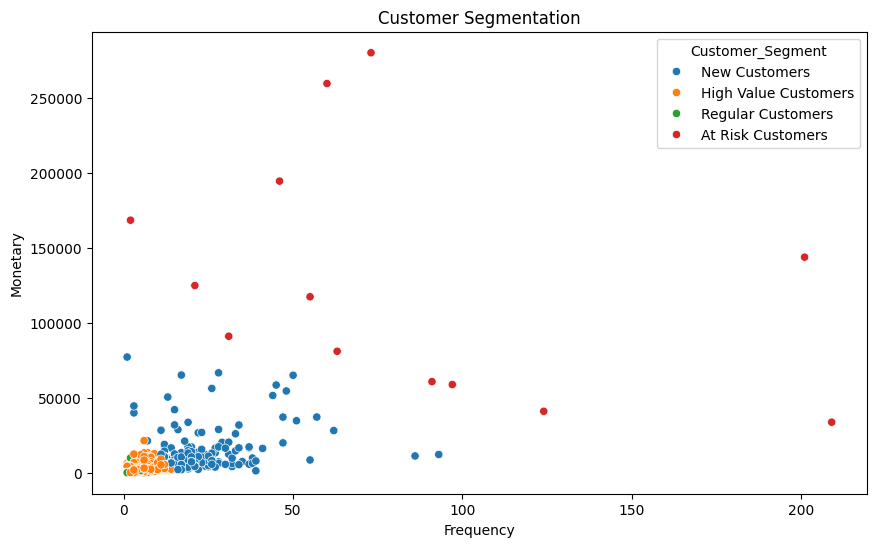

In [23]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Customer_Segment'
)

plt.title('Customer Segmentation')
plt.show()

In [24]:
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


In [25]:
rfm['Customer_Segment'].value_counts()

Customer_Segment
High Value Customers    3054
Regular Customers       1067
New Customers            204
At Risk Customers         13
Name: count, dtype: int64

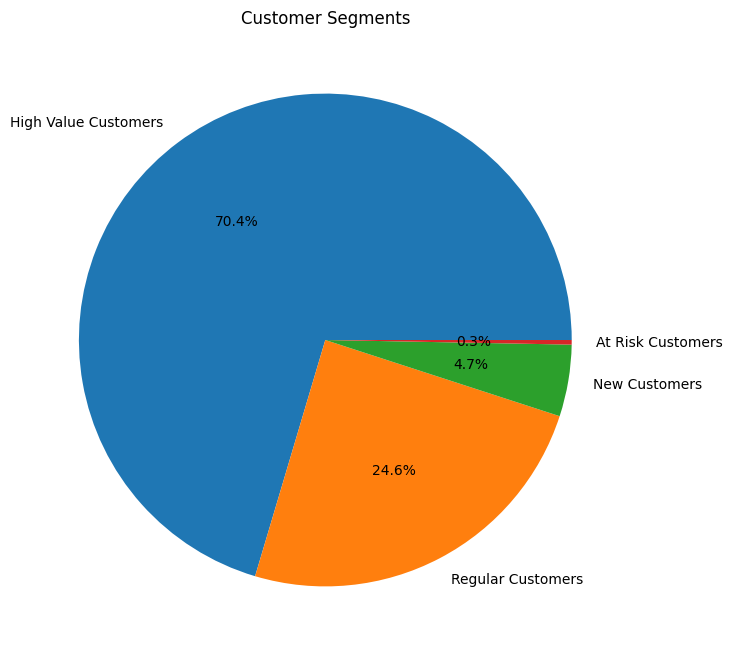

In [26]:
rfm['Customer_Segment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)
plt.ylabel('')
plt.title('Customer Segments')
plt.show()

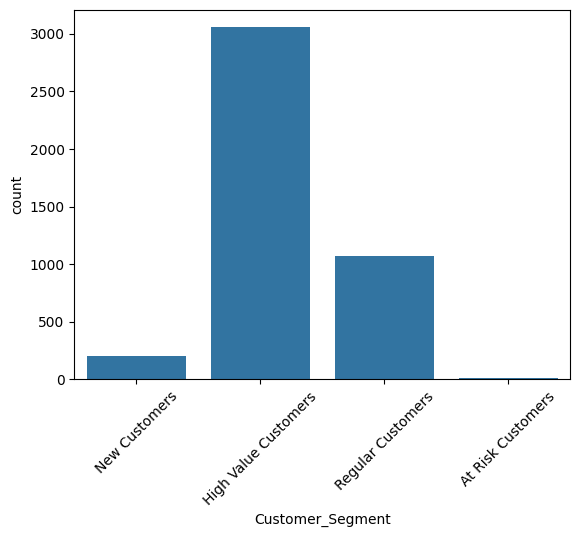

In [27]:
sns.countplot(
    x='Customer_Segment',
    data=rfm
)

plt.xticks(rotation=45)
plt.show()

In [28]:
rfm.groupby('Customer_Segment')[
    ['Recency', 'Frequency', 'Monetary']
].mean()

,Recency,Frequency,Monetary
Customer_Segment,,,
At Risk Customers,7.384615,82.538462,127338.313846
High Value Customers,43.702685,3.682711,1359.049284
New Customers,15.500000,22.333333,12709.090490
Regular Customers,248.075914,1.552015,480.617480


In [29]:
recommendations = {
    'High Value Customers':
        'Loyalty rewards, Premium membership, Personalized recommendations',

    'Regular Customers':
        'Discounts, Cross-selling, Upselling',

    'At Risk Customers':
        'Re-engagement emails, Coupons, Reminder notifications',

    'New Customers':
        'Welcome offers, First-purchase discounts'
}

rfm['Recommendation'] = (
    rfm['Customer_Segment']
    .map(recommendations)
)

rfm.head()


,Recency,Frequency,Monetary,Cluster,Customer_Segment,Recommendation
CustomerID,,,,,,
12346.0,326,1,77183.60,3,New Customers,"Welcome offers, First-purchase discounts"
12347.0,2,7,4310.00,0,High Value Customers,"Loyalty rewards, Premium membership, Personali..."
12348.0,75,4,1797.24,0,High Value Customers,"Loyalty rewards, Premium membership, Personali..."
12349.0,19,1,1757.55,0,High Value Customers,"Loyalty rewards, Premium membership, Personali..."
12350.0,310,1,334.40,1,Regular Customers,"Discounts, Cross-selling, Upselling"


In [30]:
segment_recommendations = pd.DataFrame({
    'Customer Segment': [
        'High Value Customers',
        'Regular Customers',
        'At Risk Customers',
        'New Customers'
    ],

    'Business Strategy': [
        'Loyalty rewards, Premium membership, Personalized recommendations',
        'Discounts, Cross-selling, Upselling',
        'Re-engagement emails, Coupons, Reminder notifications',
        'Welcome offers, First-purchase discounts'
    ]
})

segment_recommendations

,Customer Segment,Business Strategy
0,High Value Customers,"Loyalty rewards, Premium membership, Personali..."
1,Regular Customers,"Discounts, Cross-selling, Upselling"
2,At Risk Customers,"Re-engagement emails, Coupons, Reminder notifi..."
3,New Customers,"Welcome offers, First-purchase discounts"


In [31]:
rfm.to_csv(
    'customer_segments.csv',
    index=True
)